TODO: Swap blackjack and theory. And maybe put 'code' after blackjack, since that's where it'll start.

## Objective

This is the first notebook I make that is not a direct copy of code in the Hands-On textbook (and corresponding Github repository; link them). I am going to implement **state-value (v) iteration** and **action-value (v) iteration**, which is done there too, but without "sneaking peaks". This means referring directly to [Gymnasium](https://gymnasium.farama.org/introduction/basic_usage/) and [collections](https://docs.python.org/3/library/collections.html) sites for help with classes that I need to get things working.

There will be many cells where I isolate and test the behaviors of these classes, before implementing them.

## Environments

The cell below prints the environments available. Since I've already gone through Hands-On book, it is good to work in environments that aren't considered there.

## Strategies

Above all else, I need to make good RL code. For simple environments, it is easy to find "cheats" which can trivialize learning (I may not even need to do RL), but I should be able to do without complicated hand-engineering of data.

That being said, as the field stands I don't think generic models and methods are enough to guarantee fool-proof performance of RL agents across applications. Even a single hallucination can cost lives in applications like self-driving cars. In such applications, I believe RL should be used as an extension to the modelling done by an experienced specialist- they may provide constraints to the agent or parametrize the environment in ways that eliminate possibilities of failure on the agent's behalf. Thus, this is a skill I also wish to exercise. (It may be better off to do that as a separate project, which is why it is NOT a primary objective.)

In [1]:
import gymnasium as gym

gym.pprint_registry()

===== classic_control =====
Acrobot-v1             CartPole-v0            CartPole-v1
MountainCar-v0         MountainCarContinuous-v0 Pendulum-v1
===== phys2d =====
phys2d/CartPole-v0     phys2d/CartPole-v1     phys2d/Pendulum-v0
===== box2d =====
BipedalWalker-v3       BipedalWalkerHardcore-v3 CarRacing-v3
LunarLander-v3         LunarLanderContinuous-v3
===== toy_text =====
Blackjack-v1           CliffWalking-v1        CliffWalkingSlippery-v1
FrozenLake-v1          FrozenLake8x8-v1       Taxi-v3
===== tabular =====
tabular/Blackjack-v0   tabular/CliffWalking-v0
===== None =====
Ant-v2                 Ant-v3                 GymV21Environment-v0
GymV26Environment-v0   HalfCheetah-v2         HalfCheetah-v3
Hopper-v2              Hopper-v3              Humanoid-v2
Humanoid-v3            HumanoidStandup-v2     InvertedDoublePendulum-v2
InvertedPendulum-v2    Pusher-v2              Reacher-v2
Swimmer-v2             Swimmer-v3             Walker2d-v2
Walker2d-v3
===== mujoco =====
Ant-v4    

# Blackjack

[Here](https://gymnasium.farama.org/environments/toy_text/blackjack/) is the documentation page for this problem. Both the action and observation spaces are discrete, which makes this a relatively simple problem.

In [2]:
import gymnasium as gym
env = gym.make('Blackjack-v1', natural=False, sab=False)

In [5]:
print(env.action_space)
print(env.observation_space) # Current player sum, dealer shown value, and useable ace (bool).

Discrete(2)
Tuple(Discrete(32), Discrete(11), Discrete(2))


In [10]:
32 * 11 * 2 # Total number of states possible.

704

In [6]:
help(env.step) # This doesn't show details, because base "Env" class is wrapped by OrderEnforcing.

Help on method step in module gymnasium.wrappers.common:

step(action: 'ActType') -> 'tuple[ObsType, SupportsFloat, bool, bool, dict]' method of gymnasium.wrappers.common.OrderEnforcing instance
    Steps through the environment.



In [8]:
help(gym.Env.step) # Return: (Observation (ObsType), reward (SupportsFloat), terminated (bool), truncated (bool), info (dict))

Help on function step in module gymnasium.core:

step(self, action: 'ActType') -> 'tuple[ObsType, SupportsFloat, bool, bool, dict[str, Any]]'
    Run one timestep of the environment's dynamics using the agent actions.
    
    When the end of an episode is reached (``terminated or truncated``), it is necessary to call :meth:`reset` to
    reset this environment's state for the next episode.
    
    .. versionchanged:: 0.26
    
        The Step API was changed removing ``done`` in favor of ``terminated`` and ``truncated`` to make it clearer
        to users when the environment had terminated or truncated which is critical for reinforcement learning
        bootstrapping algorithms.
    
    Args:
        action (ActType): an action provided by the agent to update the environment state.
    
    Returns:
        observation (ObsType): An element of the environment's :attr:`observation_space` as the next observation due to the agent actions.
            An example is a numpy array cont

In [9]:
help(gym.Env.reset) # Return: (Observation (ObsType), info (dict)).

Help on function reset in module gymnasium.core:

reset(self, *, seed: 'int | None' = None, options: 'dict[str, Any] | None' = None) -> 'tuple[ObsType, dict[str, Any]]'
    Resets the environment to an initial internal state, returning an initial observation and info.
    
    This method generates a new starting state often with some randomness to ensure that the agent explores the
    state space and learns a generalised policy about the environment. This randomness can be controlled
    with the ``seed`` parameter otherwise if the environment already has a random number generator and
    :meth:`reset` is called with ``seed=None``, the RNG is not reset.
    
    Therefore, :meth:`reset` should (in the typical use case) be called with a seed right after initialization and then never again.
    
    For Custom environments, the first line of :meth:`reset` should be ``super().reset(seed=seed)`` which implements
    the seeding correctly.
    
    .. versionchanged:: v0.25
    
        T

I want to play out an episode myself, to see what it looks like. In particular, I'm interested on what `.step` returns after I stick; what does a terminal state look like?

In [117]:
def print_state(state):
    print("Player current sum: {}\nDealer's showing card value: {}\nUsable ace: {}.".format(*state))

env = gym.make('Blackjack-v1', natural=False, sab=False)
state, _ = env.reset()
print_state(state)

Player current sum: 20
Dealer's showing card value: 1
Usable ace: 0.


In [118]:
state, reward, terminated, truncated, _ = env.step(1) # Hit
print_state(state)

Player current sum: 30
Dealer's showing card value: 1
Usable ace: 0.


In [119]:
print(terminated)

True


We exceeded 21, so we went "bust" and lost. The episode ended, as confirmed by `terminated` being True.

Let's try again, this time sticking.

In [104]:
env = gym.make('Blackjack-v1', natural=False, sab=False)
state, _ = env.reset()
print_state(state)

Player current sum: 20
Dealer's showing card value: 10
Usable ace: 0.


In [105]:
state, reward, terminated, truncated, _ = env.step(0) # Stick
print_state(state)
print(reward)
print(terminated)

Player current sum: 20
Dealer's showing card value: 10
Usable ace: 0.
1.0
True


In [100]:
print(terminated)

True


In [94]:
print(reward)

1.0


# Theory of value iteration

## Value functions
The state-value function $\textit{v}(s)$ is defined by

\begin{equation}
\textit{v}(s) = \sum_a\pi(a|s) \cdot \sum_{s'}p(s'|s, a) \cdot \big[ r + \gamma \textit{v}(s') \big],
\end{equation}

where $a$ is an action, $s$ is a state, $r$ is the reward we get by transitioning from state $s$ to $s'$ by action $a$, $\pi$ is the policy, $p$ is the transition probability for the environment, and $\gamma$ is a discount factor (between 0 and 1).

By definition, the action-value function $q(s, a)$ is given by

\begin{equation}
q(s, a) = \sum_{s'}p(s'|s, a) \cdot \big[ r + \gamma \textit{v}(s') \big],
\end{equation}

which is actually a term in the equation for $\textit{v}$.

The value functions represent the expected total reward (return) of taking a series of actions and passing through a series of states in the environment during an episode.

## Policy evaluation

Now suppose our agent is following a policy $\pi$. We want to *evaluate* the policy, meaning find its value functions. Calculating the expected return from each state and action would be computationally expensive in all but the simplest environments, so we instead take an iterative approximation approach. We'll have the agent take a trajectory $s_0 \rightarrow a_0 \rightarrow r_1 \rightarrow ... \rightarrow s_{T-1} \rightarrow a_{T-1} \rightarrow r_T \rightarrow s_T$, where $T$ is the final timestep and $s_T$ is the terminal state of the episode. We make a random initial approximation $\textit{v}_0(s)$ for all states, and then iterate as

\begin{equation}
\textit{v}_{n+1} = 
\end{equation}

In practice, we may iterate until the difference between the two policies at all states is less than some quantity. 

## Policy improvement

An optimal policy $\pi^*$ is defined as one which maximises value functions (compared to other policies that may exist). **The objective of *value-based* reinforcement learning is to figure out an optimal policy for the given environment.** The agent may start with a policy that selects random actions for all states. We may then use policy evaluation to get a good approximation of $\textit{v}(s)$. Then, **for each state**, we may modify the policy to choose the action which maximises $q$. **If we keep repeating these steps, eventually the policy will converge towards the optimal policy.** This is called *policy iteration*.

## Value iteration

The cycle for policy iteration is:

1) Start with some policy $\pi$.
2) Iteratively update estimate for $\textit{v}_{\pi}(s)$ until it doesn't change much (is accurate).
3) Find new policy by selecting actions greedily with respect to $\textit{v}_{\pi}(s)$.
4) Repeat from step 2 until we get the optimal policy.

The second step is problematic, as it is effectively an iteration within an iteration, which could cause policy iteration to be slow. In *value iteration*, step 2 is reduced to a single update to the $\textit{v}_{\pi}(s)$ estimate, significantly speeding up the process without losing convergence guarantees.

## Final pseudocode

TODO: Reference Sutton and Barto, then recreate the pseudocode here for convenience. Figure out nice way to align text in markdown.

## Note on transition probabilities

The above formulas assume knowledge of $p(s'|s, a)$, which is rarely known for an environment. Typically, we are forced to collect frequency counts for $s'$ a given $(s, a) \rightarrow s'$ transitions, and use these to estimate the transition probabilities.


# Code

- We need a container to store $\textit{v}(s)$. This will likely be a dictionary. We would actually need two such containers, so that the change in value functions can be tracked and a convergence criterion specified.
- We'd need another dictionary which counts the number of times environment transitions to $s'$ from $(s, a)$ for each $s'$. This could be a `collections.defaultdict` with default value `collections.Counter`, as this makes adding new $(s, a)$ and new $s'$ counters easy.
- Need another dictionary which stores the reward for transition $(s, a) \rightarrow s'$. **For now, assume this reward is deterministic.**
- Initially, we'll start with a policy which is random selection of actions. This will populate the $(s, a) \rightarrow s'$ dictionary with transition information. We'd do this for some number of steps.
- We'd initialize the value function to be zero for all states. This initialization could be arbitrary, *except that the terminal state's value must be zero.* **Question: How do we determine the terminal state?** We'd probably need to use the `terminated` flag from the `gym` environment, but since that isn't available initially let's just set everything to zero.
- We'd have a loop where value iteration takes place.
- Finally, we'd have a container to calculate and store the optimal policy $\pi^*(s) = \displaystyle \max_{a} q^*(s, a)$.

**Notice:** There's no interaction with the environment in the value iteration loop. We only interact with a random policy to help estimate the state transition probabilities. This is unlike more advanced methods, which do collect information in the main loop.

In [10]:
import gymnasium as gym
import collections
from itertools import product

# Below: Testing how `Counter` behaves.
a = collections.Counter()
a['pog'] += 1
print(a['pog'])
print(a['cat'])

1
0


### Concern

Usually when we think of episodes in a finite MDP, we have *terminal states* which, when reached, end the episode. By definition, V(s)=0 for those states, because there's no further reward to be gained from them. Then, for states that transition towards the terminal state under $a$, $q(s, a) = r + \gamma V(s_{\text{term}}) = r$.

For the blackjack task, there are two actions: hit and stick. Hitting may lead to busting, characterized by a player card sum above 21. Such final states are all terminal states, since the game does not continue after them. 

However, the player can stick at any point and transition to the same state as they were in previously (with 100% probability). The game still ends afterwards, but if we use the formula above we'll get $q(s, a) \neq r$, which is wrong. The simplest way to deal with this is to condition `calculate_q` with a special case on 'stick'.

In [202]:
from collections import defaultdict, Counter
import numpy as np
from tqdm import tqdm

class Agent:
    def __init__(self, env, data_collection_amount, gamma):
        self.env = env
        self.data_collection_amount = data_collection_amount
        self.gamma   = gamma              # Discount factor.
        self.v_s     = defaultdict(float) # Default values are 0.0.
        self.v_s_new = defaultdict(float)
        self.transitions_dict = defaultdict(Counter)
        self.rewards_dict     = defaultdict(float)
        self.dv_list = [] # Stores metric describing change in v(s) during iteration.
        
    def random_play(self):
        # Begin the big for loop, where every iteration is an episode of random play.
        ep_count = 0
        for ep_count, _ in enumerate(tqdm(range(self.data_collection_amount))):
            state, _ = env.reset()
            done     = False
            
            # Within the 'while' loop is an episode.
            while not done:
                
                # Sample a random action, then act on environment with it.
                action = self.env.action_space.sample()
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                
                # Update transitions and rewards dictionaries.
                self.transitions_dict[(state, action)][new_state] += 1
                self.rewards_dict[    (state, action, new_state)]  = reward
                done = terminated or truncated
                
                # Don't forget to update the state.
                state = new_state
              
    def calculate_q(self, state, action):
        # `tot` will be used in probability estimation for transitions from (state, action) to a new state.
        tot  = self.transitions_dict[(state, action)].total() + 0.00001
        
        # q involves a sum over the next state. Thus, we iterate over all possible next states.
        q = 0
        for i, j, k in product(range(32), range(11), range(2)):
            new_state = (i, j, k)
            
            # We must lookup (state, action, new_state) in the transitions dictionary to find the
            # transition probability.
            prob   = self.transitions_dict[(state, action)][new_state] / tot
            reward = self.rewards_dict[(state, action, new_state)]
            value  = self.v_s[new_state] # Value of the new state, v(s').
            
            # Calculate contribution to q from 'new_state'.
            ## Here we need the condition upon the action 'stick', as discussed earlier.
            if action == 0:
                sum_component = prob * reward
            else:
                sum_component = prob * (reward + self.gamma * value)
            q += sum_component
            
        return q
        
    def update_v(self): # Single value iteration step.
        # Loop over states. State/observation space is a 3-tuple, so this means 3 loops.
        for i, j, k in product(range(32), range(11), range(2)):
            state = (i, j, k)
            
            # Calculate the q-values for all possible actions.
            q_list = [self.calculate_q(state, action) for action in [0, 1]]
            # Update v(state).
            self.v_s_new[(state)] = np.max(q_list)
            
        # Compare the old and new v(s) for all states s. This is basically a difference in vector magnitudes.
        v_s_vec     = np.array(list( self.v_s.values() ))
        v_s_new_vec = np.array(list( self.v_s_new.values() ))
        dv_vec = np.linalg.norm(v_s_vec - v_s_new_vec)
        self.dv_list.append(dv_vec)
        
        # Don't forget to update v(s).
        self.v_s = self.v_s_new.copy() # The copy operation is very important!
        
    def optimal_policy(self, state): # Assumes we finished iteration.
        # Calculate the q-values for all possible actions.
            q_list = [self.calculate_q(state, action) for action in [0, 1]]
            action = np.argmax(q_list)
            return action
        
    def play_n_episodes(self, n, use_policy=True):
        reward_list  = []
        n_steps_list = []
        
        # Repeat for n episodes.
        for _ in range(n):
            reward, n_steps = self.play_one_episode(use_policy=use_policy)
            reward_list.append(reward)
            n_steps_list.append(n_steps)
            
        return reward_list, n_steps_list
    
    def play_one_episode(self, use_policy=True):
        # Initialize params for beginning an episode.
        state, _     = env.reset()
        done         = False
        n_steps      = 0
        total_reward = 0

        # Play one episode.
        while not done:
            action = self.optimal_policy(state) if use_policy else self.env.action_space.sample()
            state, reward, terminated, truncated, _ = self.env.step(action)
            total_reward += reward # Note: We are assuming undiscounted case (gamma=1).
            n_steps += 1
            done = terminated or truncated
            
        return total_reward, n_steps

Main loop defined below.

In [211]:
env = gym.make('Blackjack-v1', natural=False, sab=False)
data_collection_amount = 25000 # This many runs to populate 'trainsitions_dict' with random policy.
gamma = 0.95
agent = Agent(env, data_collection_amount, gamma)

# Populate reward and transition data dictionaries.
agent.random_play()

100%|██████████████████████████████████████████████████████████████████████████| 25000/25000 [00:02<00:00, 12118.23it/s]


In [212]:
print(len(list(agent.rewards_dict)))
print(len(list(agent.transitions_dict)))

2642
560


In [218]:
# Collect metrics before and after iteration.
for i in tqdm(range(5)):
    agent.update_v()

reward_list0, n_steps_list0 = agent.play_n_episodes(1000, use_policy=False)
reward_list1, n_steps_list1 = agent.play_n_episodes(1000)


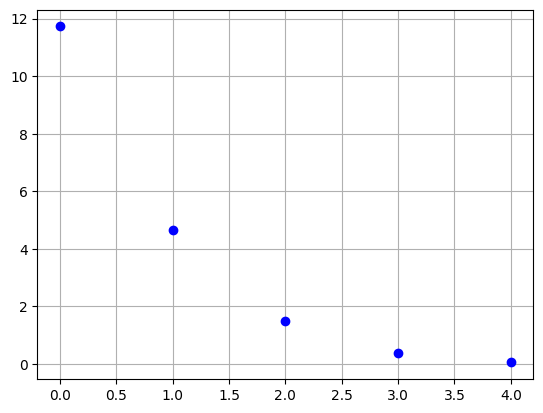

In [214]:
import matplotlib.pyplot as plt

plt.plot(np.arange(len(agent.dv_list)), agent.dv_list, 'bo')
plt.grid(visible=True)
plt.show()

**Comments:** We see that the value function changes less and less until it (almost) converges after 5 iterations. At this point, it should be close to the optimal value function, but how can we verify this?

We would need the agent to play several episodes of Blackjack, and see the average reward. Winning a game gives +1 reward, losing it gives -1, drawing gives 0. We can compare reward distributions before and after value iteration to see if there truly was an improvement.

We implemented the `play_n_episodes` method and collected mean reward before and after value iteration. Let's compare below.

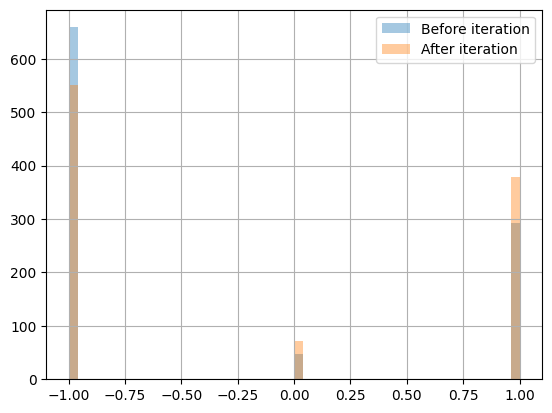

In [219]:
plt.hist(reward_list0, bins=50, alpha=0.4, label='Before iteration')
plt.hist(reward_list1, bins=50, alpha=0.4, label='After iteration')
plt.grid(visible=True)
plt.legend()
plt.show()

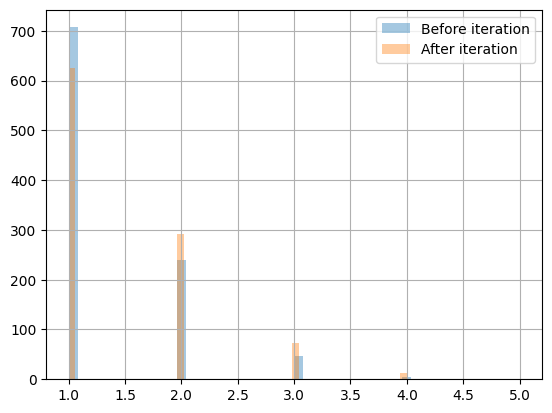

In [220]:
plt.hist(n_steps_list0, bins=50, alpha=0.4, label='Before iteration')
plt.hist(n_steps_list1, bins=50, alpha=0.4, label='After iteration')
plt.grid(visible=True)
plt.legend()
plt.show()

In [221]:
print( f"Average reward before iteration {float(np.mean(reward_list0)):.2f}." )
print( f"Average reward after  iteration {float(np.mean(reward_list1)):.2f}." )
print( f"Average episode length before iteration {float(np.mean(n_steps_list0)):.2f}." )
print( f"Average episode length after  iteration {float(np.mean(n_steps_list1)):.2f}." )

Average reward before iteration -0.37.
Average reward after  iteration -0.17.
Average episode length before iteration 1.35.
Average episode length after  iteration 1.47.


We see that after iteration, there are fewer counts of losses and greater counts of draws and wins as compared to before iteration. Furthermore, episodes last for longer on average after iteration.

I'll try this again with more random sampling, to see if the numbers change. I'll also average over a larger number of episodes, to reduce statistical uncertainty.

In [203]:
env = gym.make('Blackjack-v1', natural=False, sab=False)
data_collection_amount = 250000 # This many runs to populate 'trainsitions_dict' with random policy.
gamma = 0.95
agent = Agent(env, data_collection_amount, gamma)

# Populate reward and transition data dictionaries.
agent.random_play()

100%|████████████████████████████████████████████████████████████████████████| 250000/250000 [00:22<00:00, 11084.54it/s]


In [204]:
print(len(list(agent.rewards_dict)))
print(len(list(agent.transitions_dict)))

3079
560


In [205]:
# Collect metrics before and after iteration.
for i in tqdm(range(5)):
    agent.update_v()

100%|█████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.03it/s]


In [206]:
reward_list0, n_steps_list0 = agent.play_n_episodes(1000, use_policy=False)
reward_list1, n_steps_list1 = agent.play_n_episodes(1000, use_policy=True)

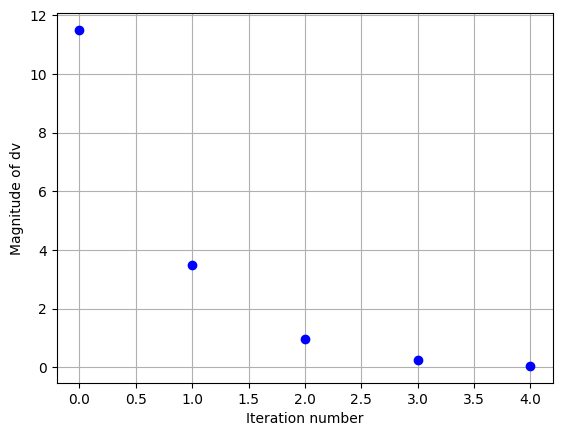

In [207]:
plt.plot(np.arange(len(agent.dv_list)), agent.dv_list, 'bo')
plt.grid(visible=True)
plt.xlabel("Iteration number")
plt.ylabel("Magnitude of dv")
plt.show()

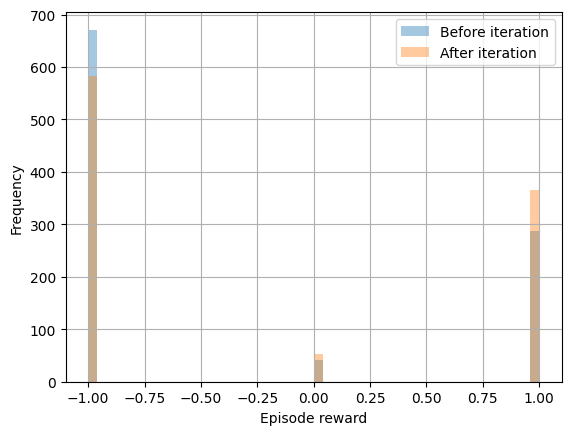

In [208]:
plt.hist(reward_list0, bins=50, alpha=0.4, label='Before iteration')
plt.hist(reward_list1, bins=50, alpha=0.4, label='After iteration')
plt.grid(visible=True)
plt.xlabel("Episode reward")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [210]:
print( f"Average reward before iteration {float(np.mean(reward_list0)):.2f}." )
print( f"Average reward after  iteration {float(np.mean(reward_list1)):.2f}." )
print( f"Average episode length before iteration {float(np.mean(n_steps_list0)):.2f}." )
print( f"Average episode length after  iteration {float(np.mean(n_steps_list1)):.2f}." )

Average reward before iteration -0.38.
Average reward after  iteration -0.22.
Average episode length before iteration 1.38.
Average episode length after  iteration 1.44.


## I don't really know if the policy I've got is the optimal one (since I don't play Blackjack). But we do see clear improvement in expected rewards.

In other environments (such as the taxi game), episodes should last longer and it should be possible to tell from a video recording if the agent is learning well or not. So, I'll move on from blackjack.